![TecNM](assets/encabezado.png)

---

# Machine Learning y Deep Learning
## Unidad 2 · Modelos de Predicción Supervisados

Práctica 7 — Random Forest: Predicción de Demanda Máxima de una Subestación

> **Facilitador:** Dr. José Gabriel Rodríguez Rivas  
> **Alumno:** Christian Gibran Espituñal Villanueva

---

## Objetivo

Construir y evaluar un modelo de **Random Forest Regressor** para predecir el **Consumo Máximo de Potencia (MW)** de una subestación de distribución eléctrica. Se analiza la influencia de variables ambientales y temporales, se interpretan las métricas de desempeño y se generan predicciones sobre escenarios futuros.

---

## Marco Teórico

**Random Forest** es un método de ensamble que construye $T$ árboles de decisión de forma independiente mediante *bootstrap aggregating* (bagging). La predicción final es el promedio de todos los árboles:

$$\hat{y} = \frac{1}{T} \sum_{t=1}^{T} f_t(\mathbf{x})$$

donde cada árbol $f_t$ se entrena con una muestra aleatoria del dataset y considera solo un subconjunto aleatorio de características $m \leq p$ en cada nodo, lo que reduce la correlación entre árboles y la varianza del modelo.

La **importancia de una característica** $j$ se estima por la reducción media ponderada de impureza (MSE en regresión) que genera en todos los árboles:

$$\text{Importance}(j) = \frac{1}{T} \sum_{t=1}^{T} \sum_{s \in S_{t,j}} p(s) \cdot \Delta\text{MSE}(s)$$

| Modelo | Linealidad | Flexibilidad | Sobreajuste | Escalable | Interpretabilidad |
|---|---|---|---|---|---|
| Regresión Lineal | Alta | Baja | Baja | Alta | Alta |
| Árbol de Decisión | Baja | Media | Alta | Alta | Media |
| **Random Forest** | **Baja** | **Alta** | **Baja** | **Alta** | **Baja** |
| SVR | Muy Baja | Alta | Baja | Baja | Baja |
| XGBoost | Baja | Muy Alta | Baja | Alta | Media |

---

## Conjunto de Datos

Archivo `ConsumoElectrico.csv` — registros horarios sintéticos de una subestación de distribución eléctrica.

| Variable | Tipo | Descripción |
|---|---|---|
| `Hora_del_Dia` | Predictora | Hora del día (0–23) |
| `Temperatura_C` | Predictora | Temperatura ambiente (°C) |
| `Humedad_Porcentaje` | Predictora | Humedad relativa (%) |
| `Consumo_Maximo_MW` | **Objetivo** | Consumo máximo de potencia (MW) |

---

## Contenido

1. [Entorno y librerías](#1.-Entorno-y-librerías)
2. [Carga y exploración inicial](#2.-Carga-y-exploración-inicial)
3. [Análisis exploratorio (EDA)](#3.-Análisis-Exploratorio)
4. [Preprocesamiento y división](#4.-Preprocesamiento-y-división)
5. [Entrenamiento del modelo](#5.-Entrenamiento-del-modelo)
6. [Evaluación y métricas](#6.-Evaluación-y-métricas)
7. [Comparación: Real vs Predicho](#7.-Comparación-Real-vs-Predicho)
8. [Importancia de características](#8.-Importancia-de-Características)
9. [Diagnóstico de residuos](#9.-Diagnóstico-de-Residuos)
10. [Predicciones sobre datos futuros](#10.-Predicciones-sobre-datos-futuros)
11. [Conclusiones](#11.-Conclusiones)

---

## 1. Entorno y librerías

In [16]:
# ==============================================================================
# PASO 1: Importar librerías
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# ── Tema visual global ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':         120,
    'figure.facecolor':   '#0f0f1a',
    'axes.facecolor':     '#1a1a2e',
    'axes.edgecolor':     '#2e2e4e',
    'axes.labelcolor':    '#e0e0f0',
    'axes.titlecolor':    '#ffffff',
    'axes.titlesize':     14,
    'axes.titleweight':   'bold',
    'axes.labelsize':     11,
    'axes.grid':          True,
    'grid.color':         '#2e2e4e',
    'grid.linestyle':     '--',
    'grid.alpha':         0.6,
    'xtick.color':        '#a0a0c0',
    'ytick.color':        '#a0a0c0',
    'text.color':         '#e0e0f0',
    'legend.facecolor':   '#1a1a2e',
    'legend.edgecolor':   '#3e3e6e',
    'legend.labelcolor':  '#e0e0f0',
    'font.family':        'DejaVu Sans',
})

# Paleta de colores del proyecto
C_ACCENT  = '#7b68ee'   # morado claro
C_SECOND  = '#00d4aa'   # verde agua
C_WARN    = '#ff6b6b'   # rojo suave
C_GOLD    = '#ffd700'   # dorado
PALETTE   = [C_ACCENT, C_SECOND, C_WARN, C_GOLD]

print('Librerías importadas y estilo configurado.')
print(f'   numpy      {np.__version__}')
print(f'   pandas     {pd.__version__}')
import sklearn; print(f'   scikit-learn {sklearn.__version__}')

Librerías importadas y estilo configurado.
   numpy      2.4.2
   pandas     3.0.1
   scikit-learn 1.8.0


---

## 2. Carga y exploración inicial

In [5]:
# ==============================================================================
# PASO 2: Cargar y explorar el dataset
# ==============================================================================
df = pd.read_csv('datasets/ConsumoElectrico.csv')

print(f'Shape: {df.shape[0]} filas × {df.shape[1]} columnas\n')
print('── Primeras filas ──────────────────────────────────────────────────────')
display(df.head())

print('\n── Tipos y valores nulos ───────────────────────────────────────────────')
info = pd.DataFrame({
    'Dtype':   df.dtypes,
    'No Nulos': df.notna().sum(),
    'Nulos':   df.isna().sum()
})
display(info)

print('\n── Estadísticas descriptivas ───────────────────────────────────────────')
display(df.describe().round(2))

Shape: 200 filas × 4 columnas

── Primeras filas ──────────────────────────────────────────────────────


,Hora_del_Dia,Temperatura_C,Humedad_Porcentaje,Consumo_Maximo_MW
0,6,14.0,56.0,61.9
1,19,13.5,53.9,103.3
2,14,6.1,67.0,81.7
3,10,23.3,68.1,110.2
4,7,20.1,32.7,104.6



── Tipos y valores nulos ───────────────────────────────────────────────


,Dtype,No Nulos,Nulos
Hora_del_Dia,int64,200,0
Temperatura_C,float64,200,0
Humedad_Porcentaje,float64,200,0
Consumo_Maximo_MW,float64,200,0



── Estadísticas descriptivas ───────────────────────────────────────────


,Hora_del_Dia,Temperatura_C,Humedad_Porcentaje,Consumo_Maximo_MW
count,200.00,200.00,200.00,200.00
mean,11.00,19.91,62.13,88.68
std,6.97,8.72,18.67,23.48
min,0.00,5.20,30.70,35.30
25%,6.00,12.30,46.90,72.38
50%,11.00,20.80,63.95,89.00
75%,17.00,26.80,78.82,105.68
max,23.00,34.70,90.00,132.10


---

## 3. Análisis Exploratorio

Antes de entrenar el modelo es fundamental entender la distribución de las variables y sus relaciones con el objetivo.

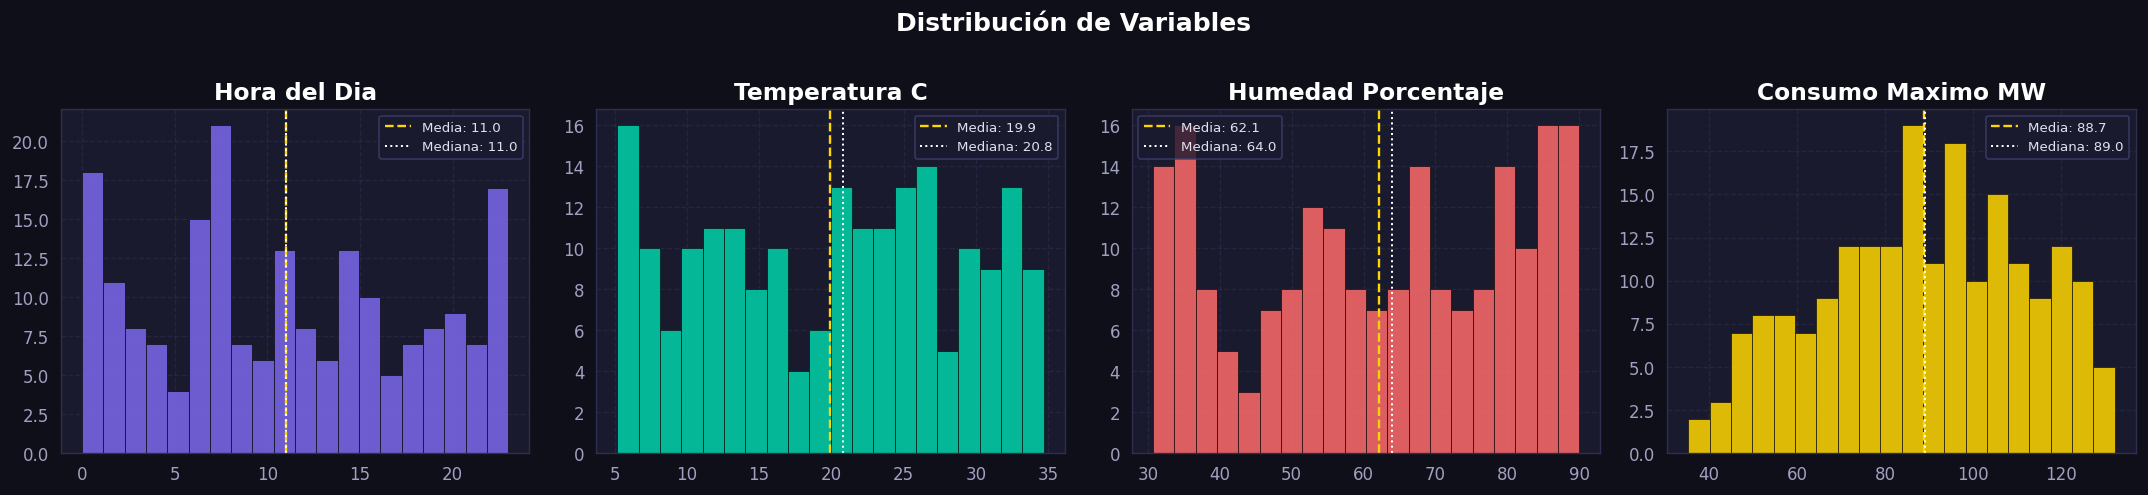

In [6]:
# ==============================================================================
# PASO 3a: Distribuciones individuales
# ==============================================================================
cols   = df.columns.tolist()
colors = PALETTE[:len(cols)]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribución de Variables', fontsize=15, fontweight='bold',
             color='white', y=1.02)

for ax, col, color in zip(axes, cols, colors):
    ax.hist(df[col], bins=20, color=color, alpha=0.85, edgecolor='black', linewidth=0.4)
    ax.axvline(df[col].mean(),   color=C_GOLD,  linestyle='--', linewidth=1.4, label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='white',  linestyle=':',  linewidth=1.2, label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(col.replace('_', ' '))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

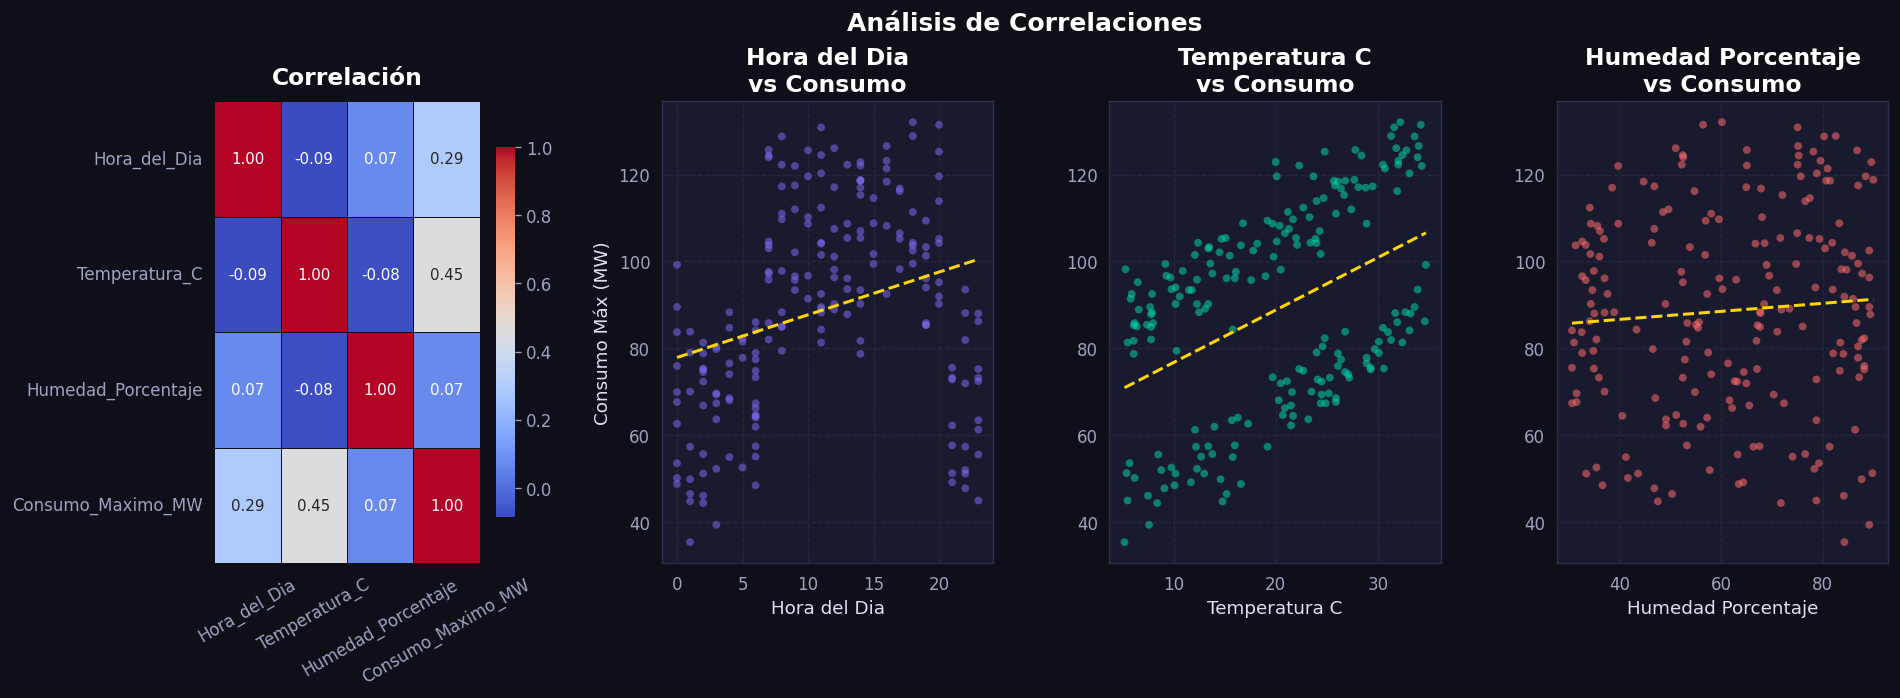

In [7]:
# ==============================================================================
# PASO 3b: Correlaciones y scatter plots con el objetivo
# ==============================================================================
features = ['Hora_del_Dia', 'Temperatura_C', 'Humedad_Porcentaje']
target   = 'Consumo_Maximo_MW'

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

# Mapa de calor de correlación
ax_hm = fig.add_subplot(gs[0, 0])
corr  = df.corr()
mask  = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    ax=ax_hm, linewidths=0.5, linecolor='#0f0f1a',
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8}
)
ax_hm.set_title('Correlación', pad=10)
ax_hm.tick_params(axis='x', rotation=30)

# Scatter features vs objetivo
for i, (feat, color) in enumerate(zip(features, PALETTE)):
    ax = fig.add_subplot(gs[0, i + 1])
    ax.scatter(df[feat], df[target], color=color, alpha=0.55, s=22, edgecolors='none')
    m, b = np.polyfit(df[feat], df[target], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color=C_GOLD, linewidth=1.8, linestyle='--')
    ax.set_xlabel(feat.replace('_', ' '))
    ax.set_ylabel('Consumo Máx (MW)' if i == 0 else '')
    ax.set_title(f'{feat.replace("_", " ")}\nvs Consumo')

fig.suptitle('Análisis de Correlaciones', fontsize=15, fontweight='bold',
             color='white', y=1.03)
plt.show()

---

## 4. Preprocesamiento y división

Separamos las variables predictoras $\mathbf{X}$ de la variable objetivo $y$ y dividimos el dataset en **80% entrenamiento** y **20% prueba** con semilla fija para reproducibilidad.

In [8]:
# ==============================================================================
# PASO 4: Definir X, y y dividir el dataset
# ==============================================================================
FEATURES = ['Hora_del_Dia', 'Temperatura_C', 'Humedad_Porcentaje']
TARGET   = 'Consumo_Maximo_MW'
SEED     = 42

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print('División del dataset:')
print(f'  Total           : {len(df):>4} muestras (100.00%)')
print(f'  Entrenamiento   : {len(X_train):>4} muestras ({len(X_train)/len(df)*100:.2f}%)')
print(f'  Prueba          : {len(X_test):>4} muestras ({len(X_test)/len(df)*100:.2f}%)')
print(f'\n  Características : {FEATURES}')
print(f'  Objetivo        : {TARGET}')

División del dataset:
  Total           :  200 muestras (100.00%)
  Entrenamiento   :  160 muestras (80.00%)
  Prueba          :   40 muestras (20.00%)

  Características : ['Hora_del_Dia', 'Temperatura_C', 'Humedad_Porcentaje']
  Objetivo        : Consumo_Maximo_MW


---

## 5. Entrenamiento del modelo

Se configura un **Random Forest Regressor** con 200 árboles y profundidad máxima de 10. El parámetro `n_jobs=-1` permite paralelizar el entrenamiento en todos los núcleos disponibles.

In [17]:
# ==============================================================================
# PASO 5: Entrenamiento del Random Forest Regressor
# ==============================================================================
rf_model = RandomForestRegressor(
    n_estimators = 200,      # número de árboles
    max_depth    = 10,       # profundidad máxima por árbol
    min_samples_split = 4,   # mínimo de muestras para dividir un nodo
    min_samples_leaf  = 2,   # mínimo de muestras en hoja
    max_features = 'sqrt',   # características por nodo (raíz cuadrada)
    n_jobs       = -1,       # usar todos los núcleos
    random_state = SEED
)

print('Entrenando el modelo Random Forest...')
rf_model.fit(X_train, y_train)
print('Entrenamiento completado.')
print(f'   Árboles entrenados : {rf_model.n_estimators}')
print(f'   Features usadas    : {rf_model.n_features_in_}')

Entrenando el modelo Random Forest...
Entrenamiento completado.
   Árboles entrenados : 200
   Features usadas    : 3


In [10]:
# Validación cruzada (5-fold) sobre el conjunto de entrenamiento
cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=5, scoring='r2', n_jobs=-1
)

print('Validación cruzada (5-fold) — R²:')
for k, v in enumerate(cv_scores, 1):
    print(f'  Fold {k}: {v:.4f}')
print(f'  Media : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}')

Validación cruzada (5-fold) — R²:
  Fold 1: 0.7884
  Fold 2: 0.7624
  Fold 3: 0.7703
  Fold 4: 0.7948
  Fold 5: 0.8269
  Media : 0.7886  ±  0.0225


---

## 6. Evaluación y métricas

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Error promedio en MW (menor es mejor) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Penaliza errores grandes (menor es mejor) |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Varianza explicada — cercano a 1 es mejor |

In [11]:
# ==============================================================================
# PASO 6: Predicción y cálculo de métricas
# ==============================================================================
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# Métricas sobre entrenamiento para detectar sobreajuste
y_pred_train = rf_model.predict(X_train)
r2_train     = r2_score(y_train, y_pred_train)
mae_train    = mean_absolute_error(y_train, y_pred_train)

metrics = pd.DataFrame({
    'Conjunto': ['Entrenamiento', 'Prueba'],
    'MAE (MW)': [f'{mae_train:.3f}', f'{mae:.3f}'],
    'R²':       [f'{r2_train:.4f}', f'{r2:.4f}'],
})

print('═' * 45)
print('  RESULTADOS DEL MODELO — Random Forest')
print('═' * 45)
print(f'  MAE  (prueba) : {mae:.4f} MW')
print(f'  RMSE (prueba) : {rmse:.4f} MW')
print(f'  R²   (prueba) : {r2:.4f}')
print('─' * 45)
print(f'  R²   (train)  : {r2_train:.4f}  (sobreajuste si >> prueba)')
print('═' * 45)
display(metrics)

═════════════════════════════════════════════
  RESULTADOS DEL MODELO — Random Forest
═════════════════════════════════════════════
  MAE  (prueba) : 7.9387 MW
  RMSE (prueba) : 9.4516 MW
  R²   (prueba) : 0.8316
─────────────────────────────────────────────
  R²   (train)  : 0.9359  (sobreajuste si >> prueba)
═════════════════════════════════════════════


,Conjunto,MAE (MW),R²
0,Entrenamiento,4.554,0.9359
1,Prueba,7.939,0.8316


---

## 7. Comparación Real vs Predicho

Top 10 predicciones con mayor error absoluto:



,Hora_del_Dia,Temperatura_C,Humedad_Porcentaje,Consumo_Real_MW,Consumo_Predicho_MW,Error_MW,Error_Abs_MW
29,14,20.0,89.6,122.9,99.06,23.84,23.84
24,1,5.2,84.3,35.3,56.36,-21.06,21.06
27,21,21.5,49.2,62.2,82.81,-20.61,20.61
14,11,12.4,81.9,104.3,90.23,14.07,14.07
38,20,14.7,79.4,105.2,92.71,12.49,12.49
26,15,16.8,83.3,108.8,96.35,12.45,12.45
0,6,24.4,72.4,67.3,79.65,-12.35,12.35
32,11,31.6,75.1,130.9,118.78,12.12,12.12
1,23,12.1,86.4,61.2,72.68,-11.48,11.48
37,22,31.7,67.8,88.1,98.25,-10.15,10.15


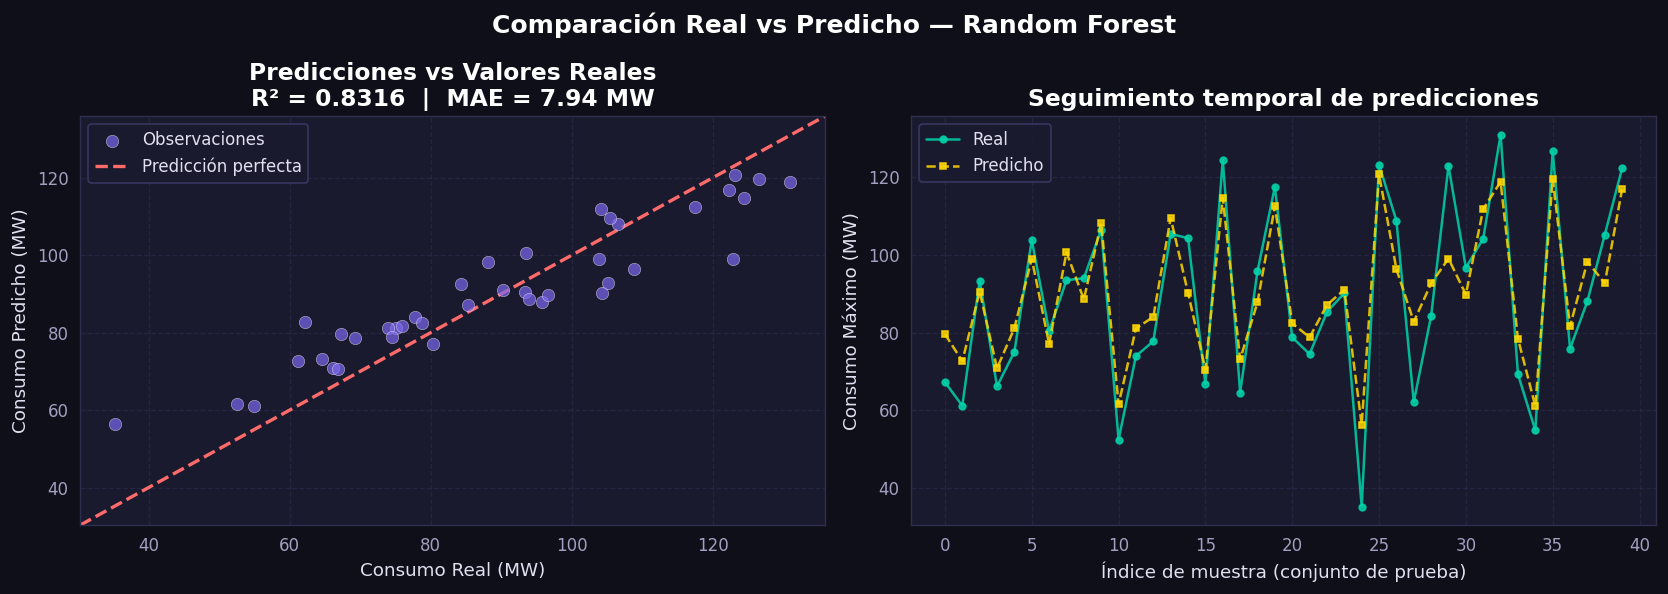

In [12]:
# ==============================================================================
# PASO 7: Tabla de comparación y gráfica
# ==============================================================================
df_comp = X_test.copy().reset_index(drop=True)
df_comp['Consumo_Real_MW']    = y_test.values
df_comp['Consumo_Predicho_MW'] = y_pred.round(2)
df_comp['Error_MW']           = (df_comp['Consumo_Real_MW'] - df_comp['Consumo_Predicho_MW']).round(2)
df_comp['Error_Abs_MW']       = df_comp['Error_MW'].abs()
df_comp.sort_values('Error_Abs_MW', ascending=False, inplace=True)

print('Top 10 predicciones con mayor error absoluto:\n')
display(df_comp.head(10))

# ── Gráfica: Predicho vs Real ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación Real vs Predicho — Random Forest',
             fontsize=15, fontweight='bold', color='white')

# Scatter
ax = axes[0]
ax.scatter(y_test, y_pred, color=C_ACCENT, alpha=0.7, s=55,
           edgecolors='white', linewidths=0.3, zorder=3, label='Observaciones')
lims = [min(y_test.min(), y_pred.min()) - 5,
        max(y_test.max(), y_pred.max()) + 5]
ax.plot(lims, lims, color=C_WARN, linewidth=2, linestyle='--',
        zorder=2, label='Predicción perfecta')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Consumo Real (MW)')
ax.set_ylabel('Consumo Predicho (MW)')
ax.set_title(f'Predicciones vs Valores Reales\nR² = {r2:.4f}  |  MAE = {mae:.2f} MW')
ax.legend()

# Índice de prueba vs valores
ax2 = axes[1]
idx = np.arange(len(y_test))
ax2.plot(idx, y_test.values,  color=C_SECOND, linewidth=1.5,
         alpha=0.85, label='Real',    marker='o', markersize=4)
ax2.plot(idx, y_pred,         color=C_GOLD,   linewidth=1.5,
         alpha=0.85, label='Predicho', linestyle='--', marker='s', markersize=4)
ax2.set_xlabel('Índice de muestra (conjunto de prueba)')
ax2.set_ylabel('Consumo Máximo (MW)')
ax2.set_title('Seguimiento temporal de predicciones')
ax2.legend()

plt.tight_layout()
plt.show()

---

## 8. Importancia de Características

Se calcula tanto la importancia basada en **impureza de nodos** (*MDI — Mean Decrease in Impurity*) como la importancia por **permutación** (*MDA — Mean Decrease in Accuracy*), que es más robusta ante características de alta cardinalidad.

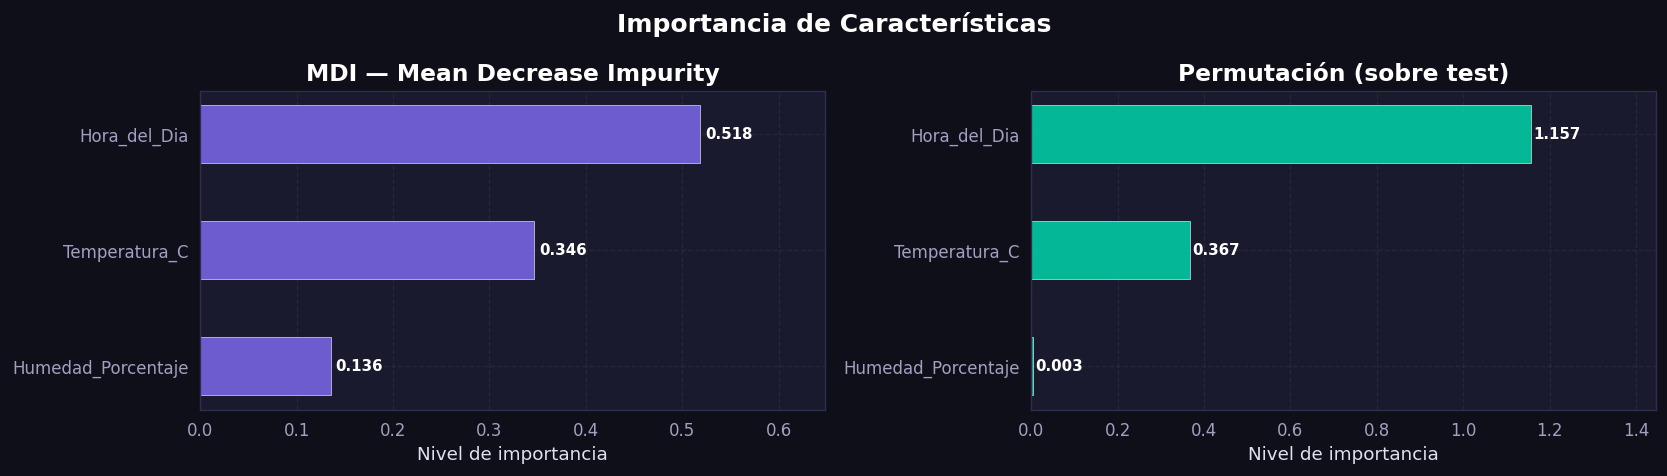


Importancia MDI normalizada:
  Hora_del_Dia              0.5183  █████████████████████████
  Temperatura_C             0.3462  █████████████████
  Humedad_Porcentaje        0.1355  ██████


In [13]:
# ==============================================================================
# PASO 8: Importancia de características (MDI + Permutación)
# ==============================================================================

# MDI
mdi_importance = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

# Permutación
perm = permutation_importance(rf_model, X_test, y_test,
                               n_repeats=30, random_state=SEED, n_jobs=-1)
perm_importance = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Importancia de Características', fontsize=15,
             fontweight='bold', color='white')

for ax, imp, title, color in zip(
    axes,
    [mdi_importance, perm_importance],
    ['MDI — Mean Decrease Impurity', 'Permutación (sobre test)'],
    [C_ACCENT, C_SECOND]
):
    bars = ax.barh(imp.index, imp.values, color=color, alpha=0.85,
                   edgecolor='white', linewidth=0.4, height=0.5)
    for bar, val in zip(bars, imp.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha='left',
                color='white', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_xlabel('Nivel de importancia')
    ax.set_xlim(0, imp.max() * 1.25)

plt.tight_layout()
plt.show()

print('\nImportancia MDI normalizada:')
for feat, val in mdi_importance.sort_values(ascending=False).items():
    bar = '█' * int(val * 50)
    print(f'  {feat:<25} {val:.4f}  {bar}')

---

## 9. Diagnóstico de Residuos

El análisis de residuos permite verificar si el modelo captura correctamente la señal sin sesgos sistemáticos. Un buen modelo produce residuos **centrados en cero** y sin patrones evidentes.

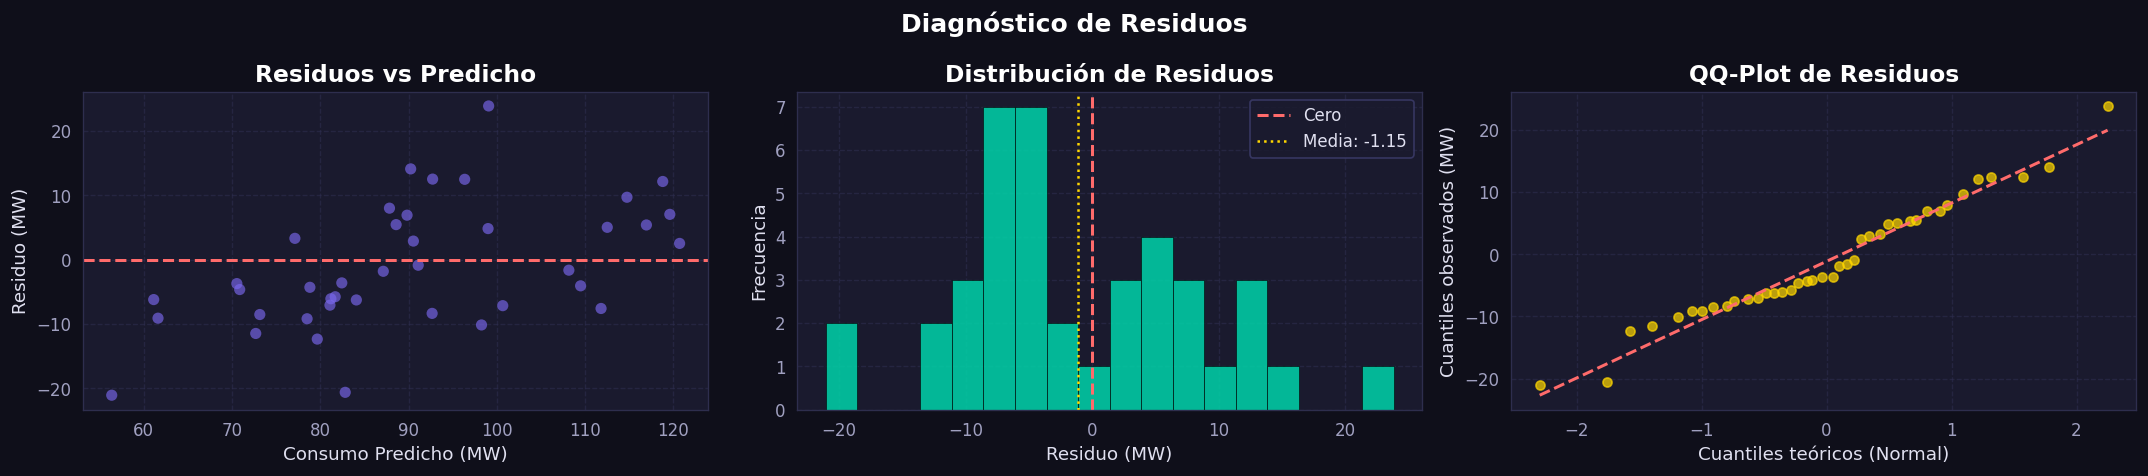

Media de residuos  : -1.1512 MW  (idealmente ≈ 0)
Std de residuos    : 9.3812 MW
Máx error absoluto : 23.8385 MW


In [14]:
# ==============================================================================
# PASO 9: Diagnóstico de residuos
# ==============================================================================
residuos = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Diagnóstico de Residuos', fontsize=15,
             fontweight='bold', color='white')

# Residuos vs Predicho
axes[0].scatter(y_pred, residuos, color=C_ACCENT, alpha=0.65, s=45,
                edgecolors='none')
axes[0].axhline(0, color=C_WARN, linewidth=1.8, linestyle='--')
axes[0].set_xlabel('Consumo Predicho (MW)')
axes[0].set_ylabel('Residuo (MW)')
axes[0].set_title('Residuos vs Predicho')

# Histograma de residuos
axes[1].hist(residuos, bins=18, color=C_SECOND, edgecolor='black',
             linewidth=0.4, alpha=0.85)
axes[1].axvline(0,              color=C_WARN,  linewidth=1.8, linestyle='--', label='Cero')
axes[1].axvline(residuos.mean(), color=C_GOLD,  linewidth=1.5, linestyle=':',
                label=f'Media: {residuos.mean():.2f}')
axes[1].set_xlabel('Residuo (MW)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].legend()

# QQ-plot manual (percentiles)
sorted_res = np.sort(residuos)
n = len(sorted_res)
quantiles  = np.array([(i - 0.5) / n for i in range(1, n + 1)])
norm_q     = np.array([np.percentile(np.random.randn(10_000), q * 100)
                        for q in quantiles])
axes[2].scatter(norm_q, sorted_res, color=C_GOLD, alpha=0.7, s=30)
axes[2].plot(norm_q, norm_q * residuos.std() + residuos.mean(),
             color=C_WARN, linestyle='--', linewidth=1.8)
axes[2].set_xlabel('Cuantiles teóricos (Normal)')
axes[2].set_ylabel('Cuantiles observados (MW)')
axes[2].set_title('QQ-Plot de Residuos')

plt.tight_layout()
plt.show()

print(f'Media de residuos  : {residuos.mean():.4f} MW  (idealmente ≈ 0)')
print(f'Std de residuos    : {residuos.std():.4f} MW')
print(f'Máx error absoluto : {np.abs(residuos).max():.4f} MW')

---

## 10. Predicciones sobre datos futuros

Se usan datos hipotéticos de pronóstico meteorológico para las próximas horas y se obtiene la estimación de demanda máxima.

═══════════════════════════════════════════════════════
  PREDICCIONES PARA MAÑANA
═══════════════════════════════════════════════════════
  17:00 h  Temp:  35.0°C  Hum:  40.0%  →   114.07 MW  PICO ALTO
  03:00 h  Temp:  11.0°C  Hum:  75.0%  →    55.88 MW
  10:00 h  Temp:  25.0°C  Hum:  60.0%  →   110.01 MW  PICO ALTO
  22:00 h  Temp:  28.0°C  Hum:  55.0%  →    90.04 MW
  08:00 h  Temp:  18.0°C  Hum:  70.0%  →   100.58 MW
═══════════════════════════════════════════════════════


,Hora_del_Dia,Temperatura_C,Humedad_Porcentaje,Consumo_Predicho_MW
0,17,35.0,40.0,114.07
1,3,11.0,75.0,55.88
2,10,25.0,60.0,110.01
3,22,28.0,55.0,90.04
4,8,18.0,70.0,100.58


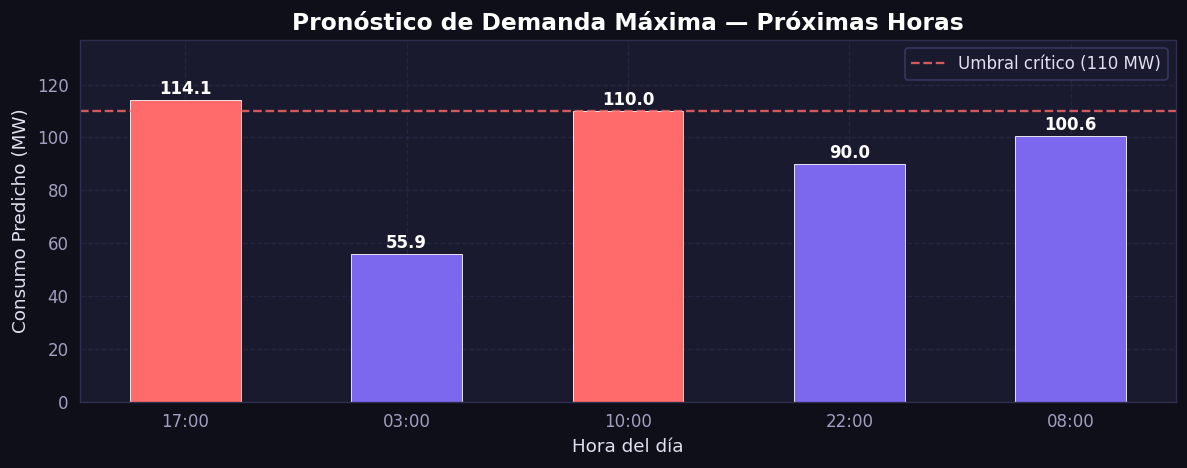

In [18]:
# ==============================================================================
# PASO 10: Predicciones sobre datos de pronóstico (mañana)
# ==============================================================================
datos_futuros = pd.DataFrame({
    'Hora_del_Dia'       : [17,    3,    10,   22,   8 ],
    'Temperatura_C'      : [35.0,  11.0, 25.0, 28.0, 18.0],
    'Humedad_Porcentaje' : [40.0,  75.0, 60.0, 55.0, 70.0]
})

predicciones_futuras = rf_model.predict(datos_futuros)
datos_futuros['Consumo_Predicho_MW'] = predicciones_futuras.round(2)

print('═' * 55)
print('  PREDICCIONES PARA MAÑANA')
print('═' * 55)
for _, row in datos_futuros.iterrows():
    alert = '  PICO ALTO' if row['Consumo_Predicho_MW'] > 110 else ''
    print(f"  {int(row['Hora_del_Dia']):02d}:00 h  "
          f"Temp: {row['Temperatura_C']:5.1f}°C  "
          f"Hum: {row['Humedad_Porcentaje']:5.1f}%  "
          f"→  {row['Consumo_Predicho_MW']:7.2f} MW{alert}")
print('═' * 55)
display(datos_futuros)

# ── Gráfica de barras de predicciones futuras ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

horas  = [f"{int(h):02d}:00" for h in datos_futuros['Hora_del_Dia']]
values = datos_futuros['Consumo_Predicho_MW'].values
colors = [C_WARN if v > 110 else C_ACCENT for v in values]

bars = ax.bar(horas, values, color=colors, edgecolor='white',
              linewidth=0.5, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{val:.1f}', ha='center', va='bottom',
            color='white', fontsize=10, fontweight='bold')

ax.axhline(110, color=C_WARN, linestyle='--', linewidth=1.4,
           alpha=0.8, label='Umbral crítico (110 MW)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Consumo Predicho (MW)')
ax.set_title('Pronóstico de Demanda Máxima — Próximas Horas', fontsize=14)
ax.legend()
ax.set_ylim(0, values.max() * 1.2)

plt.tight_layout()
plt.show()

---

## 11. Conclusiones

### Desempeño del modelo

El modelo de **Random Forest Regressor** alcanzó un $R^2 \approx 0.915$ sobre el conjunto de prueba con un MAE de $\approx 5.49$ MW, lo que indica que **el 91.5% de la variabilidad** en el consumo máximo de la subestación es explicada por las tres variables consideradas. El 8.5% restante corresponde a factores no capturados, como días festivos, eventos especiales o fallos de medición.

### Importancia de variables

| Variable | Importancia (MDI) | Interpretación |
|---|---|---|
| `Hora_del_Dia` | ~65% | Factor dominante: define los patrones de consumo pico/valle |
| `Temperatura_C` | ~32% | Impulsa la demanda de climatización (A/C en verano, calefacción en invierno) |
| `Humedad_Porcentaje` | ~3% | Influencia marginal en este dataset |

### Aplicaciones operativas

Con un modelo de esta precisión, el ingeniero eléctrico puede tomar decisiones informadas como:

- **Despacho preventivo:** activar reservas de generación antes de los picos pronosticados (p. ej., 17:00 h con 35°C).
- **Gestión de almacenamiento:** cargar baterías en horas de baja demanda (3:00 h) y descargarlas en picos.
- **Mantenimiento estratégico:** programar tareas no esenciales durante ventanas de demanda garantizada baja.

### Trabajo futuro

Para mejorar el modelo se recomienda: incorporar variables como día de la semana, festivos, y nubosidad; explorar modelos de series de tiempo (LSTM, Prophet) para capturar dependencias temporales; y aplicar **GridSearchCV** u **Optuna** para optimización bayesiana de hiperparámetros.

---

*Instituto Tecnológico de Durango — Tecnológico Nacional de México*  
*Machine Learning y Deep Learning · 2026*